_You can write your names and project group here_


# Image reconstruction using probabilistic Principal Component Analysis

## Foreword

####  Principal Component Analysis
Principal Component Analysis (PCA) is the oldest and most common technique for _dimensionality reduction_: we want to represent points $\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n$ from a multidimensional space $\mathbb{R}^D$ and _embed_ them into a smaller subspace $\mathbb{R}^M$. The strategy in the case of PCA is to sequentially maximize the variance explained by each subspace $\mathbf{u}_1, \mathbf{u}_2, \ldots, \mathbf{u}_M \in \mathbb{R}^D$. We can represent the approximation of the $\mathbf{x}_i$ by its coordinates in the new system: 
$$
\mathbf{z} = (z_1, \ldots, z_M)^{T} = (\mathbf{u}_1^T \mathbf{x}, \ldots, \mathbf{u}_M^T \mathbf{x})
$$

#### Probabilistic formulation of PCA

An equivalent probabilistic formulation of PCA is to consider a hierarchical model with a latent variable $\mathbf{z} \in \mathbb{R}^M$ drawn from a isotropic gaussian, and then a projection using the matrix $W$ ($I_{D}$ is the identity matrix in $\mathbb{R}^{D\times D}$):
\begin{align*}
\mathbf{z} & \sim \mathcal{N}(0, I_{M}) \\
\mathbf{x} & = W \mathbf{z} + \mu + \varepsilon \\
\varepsilon & \sim \mathcal{N}(0, \sigma^2 I_{D} )
\end{align*}

#### Generalisation of PCA: Latent Factor Analysis
If we take out the hypothesis that the noise is isotropic, we have a model called *Latent Factor Analysis* or *Factor Analysis* (FA), where this time $\varepsilon$ has a diagonal covariance $\Psi$ ($\varepsilon \sim \mathcal{N}(0,\Psi)$). We will use this model in the following or more precisely an extension of it to mixture (mixture of factor analysers).


## Outline of the Project

In this project we will revisit the MNIST dataset using first PCA. We will then move to the probabilistic formulation and consider mixtures of pPCA/FA and see how they allow to embed the image space in a series of components with different dimensions.
We can note that this unsupervised learning approach is complementary another unsupervised learning approach we saw previously. Indeed, in project 3, we applied clustering on the same dataset. We will see how dimensionality reduction provides another way to perform image imputation. 

The project is divided into 4 parts:

1. Data loading and preprocessing.
2. Applying Principal component analysis to the data and evaluation of the approximation.
3. Applying mixtures of probabilistic PCA and Factor Analysis and evaluation of the results for data representation.
4. Using mixture of pPCA/Factor Analysers for image imputation, and compare it with the clustering results (optional)

## 1. Data loading and preprocessing


For this project, it is necessary to install the following packages for data download and for estimating Mixture of Factor analyzers:
- PyTorch 
- PyTorch lightning 

We will also make use of a published module that performed pPCA and LFA for a [paper comparing Generative Adversarial Networks with Gaussian Mixture Models](https://arxiv.org/abs/1805.12462). The original implementation in [tensorflow is here](https://github.com/eitanrich/gans-n-gmms) and the more recent pytorch version can be found [here](https://github.com/eitanrich/torch-mfa). No need to download those modules for the project, as all the necessary functions have been provided in the `mfa_helpers.py` accompanying file.




In [9]:
from data import CelebADataset

from pathlib import Path

from PIL import Image
from matplotlib import pyplot as plt

from torchvision.datasets import MNIST

from mfa_helpers import *

import torchvision.transforms as transforms


torch.manual_seed(666)


### Load and represent the data

We will start by loading the data and normalizing it with the corresponding torch data loader. We will use the torch function to load the data and transform it into flat vectors from the beginning on. Note that in this case we apply Torch functions for reshaping the tensors.


### Preparing dataset

In [10]:

## The transform options reads the data and renormalizes it
## to a one dimensional vector. 

## it is also possible to download the MNIST.zip archive and uncompress it in a data subfolder

train_dataset = MNIST(
    root='./data',
    train=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        ReshapeTransform([-1])
    ]),
    download=True
)
test_dataset = MNIST(
    root='./data',
    train=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        ReshapeTransform([-1])
    ]),
    download=True
)





100%|██████████| 9.91M/9.91M [00:09<00:00, 1.05MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 292kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.23MB/s]


### Plotting functions

We provide below some new plotting functions. Those function are provided as they can be adapted to color images, but you can also use the function from project 3 if you prefer. 


In [ ]:

def samples_to_np_images(samples, image_shape=[64, 64, 3], clamp=True):
    assert len(samples.shape) == 2
    assert samples.shape[1] == np.prod(image_shape)
    assert len(image_shape) == 2 or (len(image_shape) == 3 and image_shape[2] > 1)
    samples_out = samples if not clamp else torch.clamp(samples, 0., 1.)
    if len(image_shape) == 3:
        return samples_out.reshape(-1, image_shape[2], image_shape[0], image_shape[1]).permute(0, 2, 3, 1).cpu().numpy()
    else:
        return samples_out.reshape(-1, image_shape[0], image_shape[1]).cpu().numpy()


def sample_to_np_image(sample, image_shape=[64, 64, 3]):
    return samples_to_np_images(sample.unsqueeze(0), image_shape).squeeze()


def samples_to_mosaic_any_size(grid_size, samples, image_shape=(64, 64, 3)):
    images = samples_to_np_images(samples, image_shape)
    num_cols = grid_size[1]
    num_rows = grid_size[0]
    rows = []
    for i in range(num_rows):
        rows.append(np.hstack([images[j] for j in range(i * num_cols, (i + 1) * num_cols)]))
    return (np.vstack(rows) * 255).astype(np.uint8)




**Question 1.1**: Plot a 10 samples from the MNIST dataset, as a matrix with two rows and five columns. 

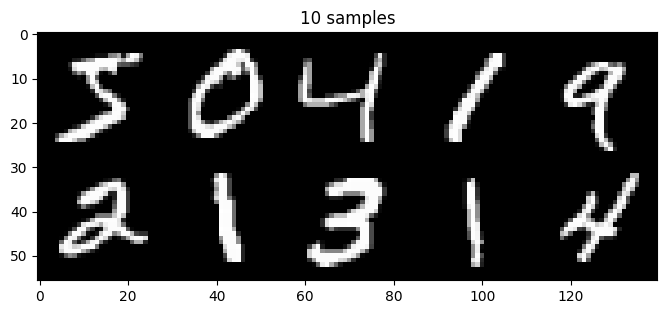

In [16]:
samples_10 = torch.stack([train_dataset[i][0] for i in range(10)])

mosaic = samples_to_mosaic_any_size(
    grid_size=(2, 5),
    samples=samples_10,
    image_shape=(28, 28)
)

plt.figure(figsize=(8, 4))
plt.imshow(mosaic, cmap='gray')
plt.title("10 samples")
plt.show()

**Question 1.2**: explicit how the images are expanded as vector by the pytorch functions:
 - What are the dimension of an image in the MNIST dataset? 
 - How are the matrix coordinates $(x,y)$ of a pixel converted into an index $z$ when they are transformed into a flat vector?

A MNIST image has the shape 28 x 28 pixels and can be flatten in a vector of the size 784.

The rows are stacked after each other, so the flatten index is: x * 28 + y

## 2. Applying PCA to the MNIST dataset

In this part we will first analyse the MNIST dataset and try to reduce the number of dimensions using PCA. First we will try to understand what are the groups of pixels that contribute to the most variability in one digits, and see how this information can be used for compression of the images. We will also apply PCA to the whole set and set what it implies for continuous representations.

- To apply PCA, you can for instance use the `sklearn` module that was proposed in the last project, after converting the data vectors. 

- By default, you can consider the train cut of the dataset, even though in this part of the project, the train/test separation is not important. 



**Question 2.1**: Choose one of the digit in the MNIST dataset and fit a Principal Component Analysis on the samples for that digit (`3` is the digit used in the Bishop): 
- Represent the mean and the first 3 principal components' basis vectors for that image. As the PC can contain negative values, renormalize the values between 0 and 1 before plotting (0 values will be plotted as grey pixels). 
- Represent the proportion of the variance captured by the principal components as a function of the number of components (you can go up to 200 components).
- How many components are needed to be able to capture more that 80%, 90% or 95% of the variance? 

  


In [18]:
# Your code here. 

X, Y = [], []
for image, label in train_dataset:
    if label == 3:
        X.append(image.numpy())
        Y.append(label)

X = np.array(X)
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6131, 784), dtype=float32)

In [29]:
from sklearn.decomposition import PCA
pca = PCA(n_components=250)
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",250
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

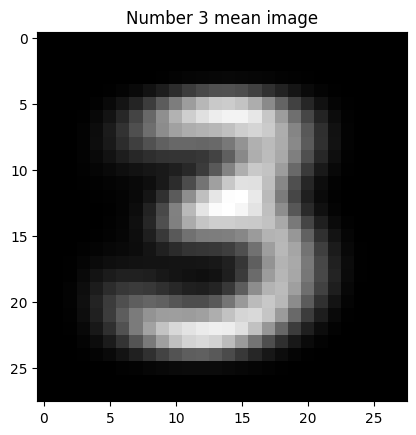

In [30]:
mean_image_3 = pca.mean_.reshape(28, 28)

plt.imshow(mean_image_3, cmap='gray')
plt.title("Number 3 mean image")
plt.show()

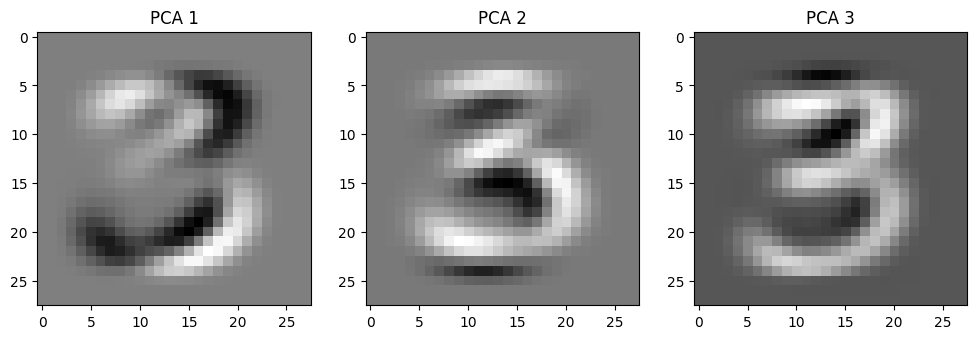

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for i in range(3):
    image = pca.components_[i].reshape(28,28)

    image = image - image.min()
    image = image / image.max()

    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"PCA {i+1}")

plt.show()

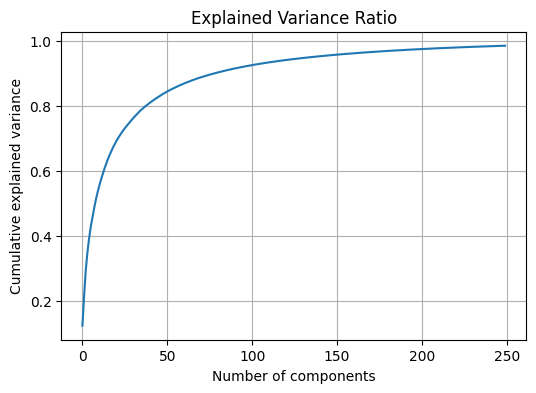

In [32]:
explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(explained_variance_ratio)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Explained Variance Ratio")
plt.grid()
plt.show()

In [33]:
thres08_n_components = np.argmax(explained_variance_ratio >= 0.8) + 1
thres09_n_components = np.argmax(explained_variance_ratio >= 0.9) + 1
thres095_n_components = np.argmax(explained_variance_ratio >= 0.95) + 1

print(f"0.8% -> {thres08_n_components} components ")
print(f"0.9% -> {thres09_n_components} components ")
print(f"0.95% -> {thres095_n_components} components ")

0.8% -> 39 components 
0.9% -> 80 components 
0.95% -> 138 components 


39 components are necessary for a variancde of minimum 0.8%, 80 for minimum of 0.9% and 138 for minimum of 0.95% variance.

**Question 2.2**: For the digit that was chosen, we will now take one sample and reconstruct it using $M=1, 10, 50$, and $250$ principal components. Let's have a look at the results:
- Plot the original and the reconstructed images, as show below for the digit `3` (taken from the chapter 12 of the Bishop book).
- What is the compression ratio achieved for each value of $M$?
- What is the Mean-Squared Error achieved (over all pixel) for each values of $M$? 



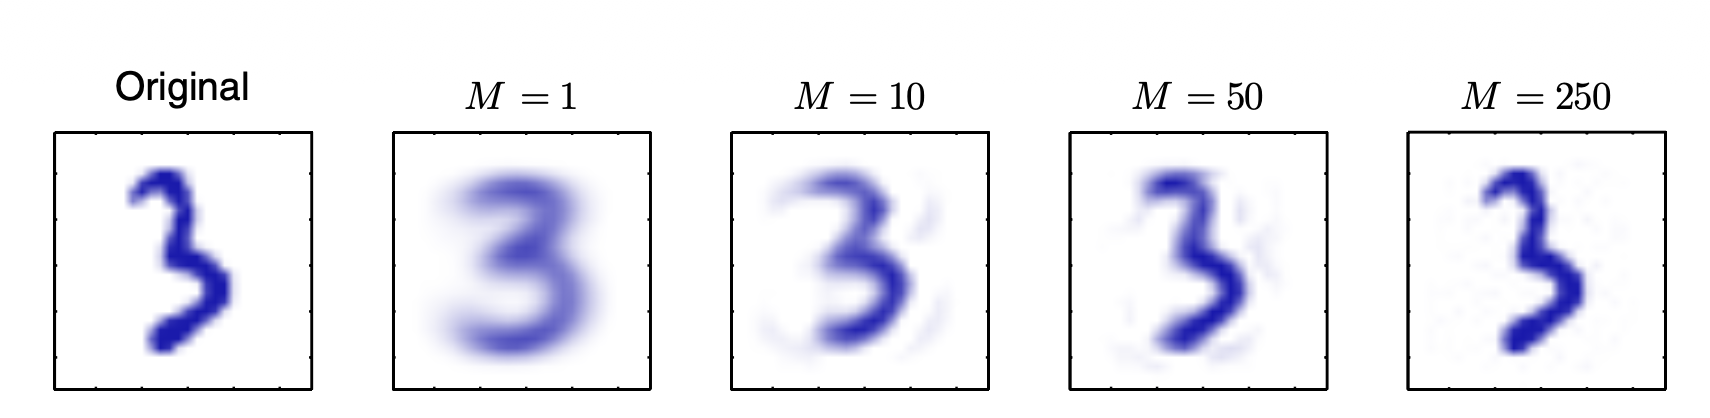

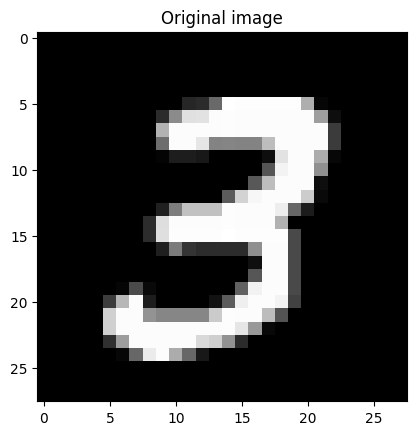

In [37]:
## Your code here 

sample = X[0]
sample_image = sample.reshape(28,28)

plt.imshow(sample_image, cmap='gray')
plt.title("Original image")
plt.show()


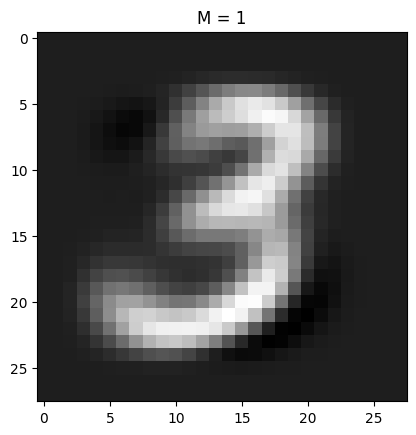

M = 1: ratio = 784.00
M = 1: MSE = 0.038055


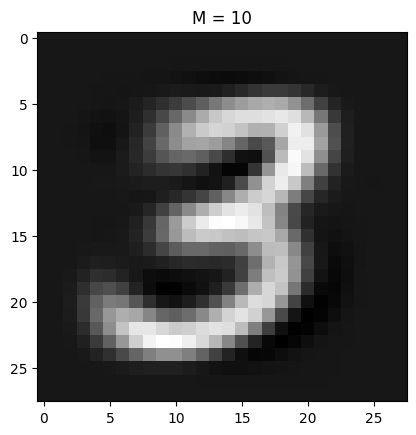

M = 10: ratio = 78.40
M = 10: MSE = 0.013065


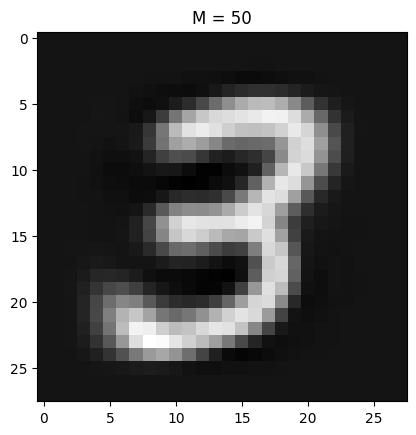

M = 50: ratio = 15.68
M = 50: MSE = 0.007511


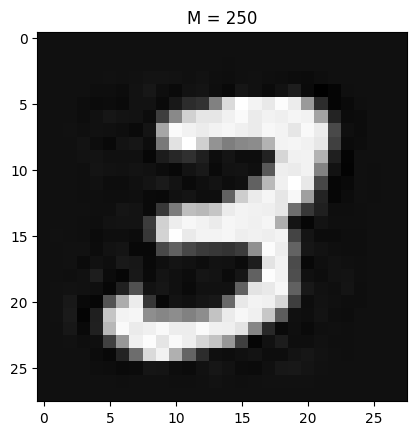

M = 250: ratio = 3.14
M = 250: MSE = 0.000592


In [40]:
from sklearn.metrics import mean_squared_error
m_values = [1, 10, 50, 250]

for m in m_values:

    m_components = pca.components_[:m]
    mean = pca.mean_
    
    coe = np.dot(sample - mean, m_components.T)
    m_image = mean + np.dot(coe, m_components)    
    
    m_image = m_image.reshape(28,28)

    plt.imshow(m_image, cmap='gray')
    plt.title("M = " + str(m))
    plt.show()

    ratio = 784 / m
    print(f"M = {m}: ratio = {ratio:.2f}")

    mse = mean_squared_error(sample, m_image.flatten())
    print(f"M = {m}: MSE = {mse:.6f}")


**Question 2.3**: We will now apply PCA to the MNIST dataset with *all digits*. The idea is to see how the different digits are represented on the first principal components and how the dimensionality reduction still allows compression:
- Represent the samples on the first two principal components with a pairplot. You can take for instance `0`, `1`, and `2` and plot them in 3 different colors.
     1.  How are the digits occupying the plane? Do you notice some grouping?
     2.  Consider one digit and spread on the plane, how do they change as you move along?
- Represent the mean and the first 3 Principal Components, as in question 2.1.
- Redo the compression experiment for the sample you considered in Q2.2, how are the reconstruction and the MSE now?



In [41]:
## Your code here

X_all, Y_all = [], []

for image, label in train_dataset:
    X_all.append(image.numpy())
    Y_all.append(label)

X_all = np.array(X_all)
Y_all = np.array(Y_all)

pca_all = PCA(n_components=250)
X_pca = pca_all.fit_transform(X_all)

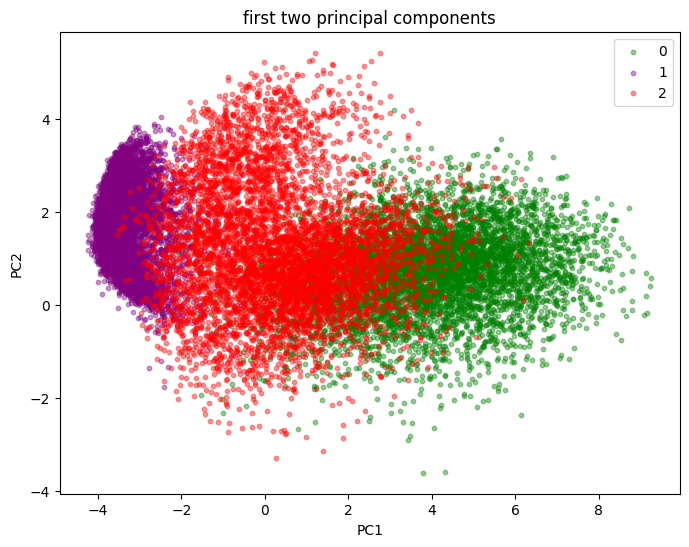

In [43]:
numbers = [0, 1, 2]
colors = ['green', 'purple', 'red']

plt.figure(figsize=(8,6))

for number, color in zip(numbers, colors):
    idx = Y_all == number
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, label=str(number), alpha=0.4, s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("first two principal components")
plt.show()

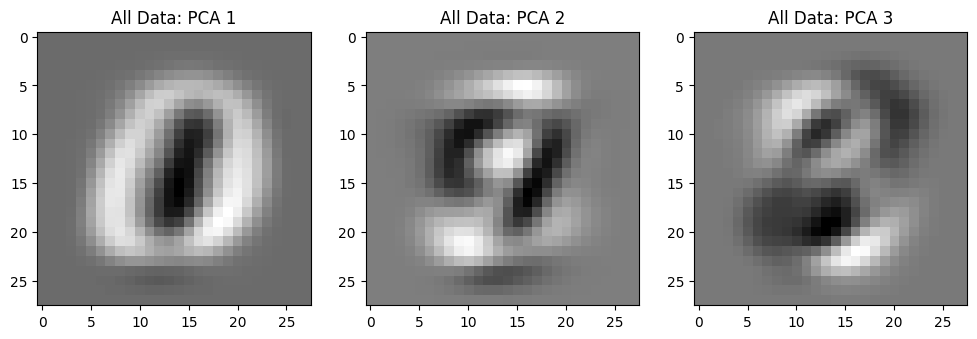

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for i in range(3):
    image = pca_all.components_[i].reshape(28,28)

    image = image - image.min()
    image = image / image.max()

    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"All Data: PCA {i+1}")

plt.show()

## 3. Using MFA/MPPCA on the MNIST dataset

In this part we will train different mixture of factor analysis (MFA) models on the MNIST dataset and see how it performs. 
A mixture of factor analyser correspond to $K$ latent variables $\mathbf{z}_1, \ldots, \mathbf{z}_K$ which have each a number of factors $M$ (dimensionality reduction). 

We can write it as an extension of the previous pPCA and FA to mixtures:
$$
\mathbf{x} = \sum_{k=1}^{K} \pi_k\cdot W_k \mathbf{z}_k + \mu_k + \varepsilon_k
$$
Like for pPCA, $\mathbf{z_k} \sim \mathcal{N}(0, I_{M})$, and 
$\varepsilon_k \sim \mathcal{N}(0, \Psi_k)$


### Model training

The training of the model can be done by specifying its parameters with the `MFA` class, and then using the `batch_fit` torch primitive. 

The class `MFA` contains the following set of parameters (more details in `mfa.py`):
  - `n_features`: the number of features $D$
  - `n_components`: the parameter $K$
  - `n_factors`: the parameter $M$
  - `common_subspace`: a tensor of all the matrices $W_k$ of shape `[K, D, M]`.
  - `log_component_variances`: a tensor of the log variances $\log \Psi_k$ of shape `[K, D]`.
  - `PI_logits`: vector of the log-mixing coefficients: $(\log \pi_k)_{k=1,\ldots, K}$.

To create a new model with no fixed parameters, you just need to specify `n_features`, `n_components`, and `n_factors`. 
You can then use the torch primitive `batch_fit`. We recommend using the following parameters for training:
- maximum of 10 EM steps
- a batch size of 128 samples.

All default parameters are provided in the example code below. The manipulation of such models is more involved, so in this part of the project you are expected to manipulate helpers functions and provide comments and interpretations at each step of the analysis.

**Question 3.1**: Let's consider the basic properties of pPCA/FA and their mixture versions:
- Verify that the number of free parameters for a probabilistic PCA is $D(M+1) +1$ and $D(M+2)$ for a single factor analyzer
- What are the number of parameters for a mixture of factor analyzers?



**Question 3.2**: Let's see how the MFA model can be trained on the MNIST dataset. We will fix $M$ the number of factors/PC to $2$, and vary $K$, the number of components.
- **a**. Train an MFA with $K=10$ components on the MNIST dataset (example code is provided below)
- **b**. For each component in the mixture, represent the mean and the first Principal Components. You can help yourself with the `visualize_model` helper function. What do you notice about the components? 
- **c**. Train other models with $K=20$ and $K=50$ components and compare the likelihoods. 
- **d**. Check how the reconstruction works for one digit with $K=10, 20, 50$ (you can use the same digit as the one you used in part 2). Report the MSE of the reconstructions as well. What the compression ratio in that case? 


In [4]:
##
## Parameters for running the mixture of components
## 

## This bolean switch allows to load an already trained model
retrain = False
##
image_shape = [28, 28]  # The input image shape
n_components = 10  # Number of components in the mixture model
n_factors = 2  # Number of factors - the latent dimension (same for all components)
batch_size = 128  # The EM batch size
num_iterations = 10

## Template model_name to save the results in a folder
model_name = f'MNIST_{n_components}_l_{n_factors}_iter_{num_iterations}'

## preparing folder for saving the models and the figures
device = torch.device('cpu')
model_dir = Path('models/')
model_dir.mkdir(parents=True, exist_ok=True)
figures_dir = Path('./figures/') / model_name
figures_dir.mkdir(exist_ok=True, parents=True)
model_path = Path(model_dir / f'model_{model_name}.pth')

## Defining an MFA model, only needs K, D, and M.
print('Defining the MFA model...')
model = MFA(
    n_components=n_components,
    n_features=np.prod(image_shape),
    n_factors=n_factors,
).to(device=device)

## Model training, note the retrain boolean to allow reloading a model.
ll_log = []
if not retrain and model_path.exists():
    print('Loading existing model...', end='')
    load = torch.load(model_path, weights_only=True)
    model.load_state_dict(load)
    print('Done.')
else:
    print(f'EM fitting: {n_components=} / {n_factors=} / {batch_size=} ...')

    ll_log = model.batch_fit(
        train_dataset,
        test_dataset,
        batch_size=batch_size,
        max_iterations=num_iterations,
    )

    print('Saving the model...', end='')
    torch.save(model.state_dict(), model_path)
    print('Done.')

Defining the MFA model...
EM fitting: n_components=10 / n_factors=2 / batch_size=128 ...
Random init with 6 samples per component...
Iteration 0/10, log-likelihood=-46.28341293334961:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 94.81it/s] 

M-step: updating parameters

 (5.03 sec)
Iteration 1/10, log-likelihood=125.18628692626953:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 106.03it/s]

M-step: updating parameters

 (4.45 sec)
Iteration 2/10, log-likelihood=147.08302307128906:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 116.15it/s]

M-step: updating parameters

 (4.05 sec)
Iteration 3/10, log-likelihood=157.10446166992188:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 107.55it/s]

M-step: updating parameters

 (4.38 sec)
Iteration 4/10, log-likelihood=163.30178833007812:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 109.07it/s]

M-step: updating parameters

 (4.32 sec)
Iteration 5/10, log-likelihood=168.80221557617188:


E-step: processing batches: 100%|██████████| 469/469 [00:03<00:00, 119.68it/s]

M-step: updating parameters

 (3.94 sec)
Iteration 6/10, log-likelihood=171.2509307861328:


E-step: processing batches: 100%|██████████| 469/469 [00:03<00:00, 118.83it/s]

M-step: updating parameters

 (3.97 sec)
Iteration 7/10, log-likelihood=172.98931884765625:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 115.29it/s]

M-step: updating parameters

 (4.09 sec)
Iteration 8/10, log-likelihood=174.43174743652344:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 111.32it/s]

M-step: updating parameters

 (4.24 sec)
Iteration 9/10, log-likelihood=175.5763702392578:


E-step: processing batches: 100%|██████████| 469/469 [00:03<00:00, 118.80it/s]

M-step: updating parameters (3.97 sec)

Final train log-likelihood=176.8585968017578:
Saving the model...Done.


In [ ]:
## Your code here

In [5]:
# For question 3.2.b
# Visualizes the components of the trained MFA model. 
# The header shows the mean and the std. dev. of each component. 
# The rows below show the factors: mean, direction/factor loadings, and
# mean - direction/factor loadings.

print('Visualizing the trained model...')
image_mode = 'L' if len(image_shape) == 2 else 'RGB'
model_image = visualize_model(model, image_shape=image_shape, end_component=10)
img = Image.fromarray(model_image, mode=image_mode)
img.show()
img.save(figures_dir / 'model_vis.png')




Visualizing the trained model...


In [ ]:
## Your code/comments here

### Simulating samples 


**Question 3.3**: We want to see how it works with simulation. On the model with $K=10$ and the one with $K=50$ components, simulate a hundred samples and plot them. Compare the properties of the samples for the different number of components.

Below an example code to generate samples and plot them.

In [6]:

print('Generating random samples...')
rnd_samples, _ = model.sample(100)
mosaic = samples_to_mosaic(rnd_samples, image_shape=image_shape)
img = Image.fromarray(mosaic)
img.show()
img.save(figures_dir / 'samples.png')



Generating random samples...


In [ ]:
## You code/comments here

### Visualizing the embeddings. 

**Question 3.4**: Having an embedding in the latent space enables to maps the point in the training samples to a continuous representation. The code below is a way to represent the latent space of each component on a grid. Please describe what the code below is doing and provide a short comparison between the grids for $K=10$ and $K=50$ components. 

In [7]:
## Visualizing latent space by generating samples from a grid in the latent space

## Function for generating the samples
def generate_sample_from_latents(model, latents, component=None):
    if torch.all(model.common_subspace == 0.0):
        warnings.warn("SGD MFA training requires initialization. Please call batch_fit() first.")
    # assert latents.shape[1] == model.n_factors
    n = latents.shape[0]

    if component is None:
        c_nums = np.random.choice(
            model.n_components,
            n,
            p=torch.softmax(model.PI_logits, dim=0).detach().cpu().numpy(),
        )
    else:
        c_nums = torch.full((latents.shape[0], ), component, dtype=torch.int)
        padded_latents = torch.zeros((latents.shape[0], model.n_factors), device=latents.device)
        padded_latents[:, :latents.shape[1]] = latents

    z_d = torch.zeros(n, model.n_features, device=model.common_subspace.device)

    samples = torch.stack(
        [
            model.common_subspace[c_nums[i]] @ padded_latents[i]
            + model.means[c_nums[i]]
            + z_d[i] * torch.exp(0.5 * model.log_component_variances[c_nums[i]])
            for i in range(n)
        ]
    )

    return samples, c_nums

def grid_to_image(grid_coords, samples, image_shape=(64, 64, 3)):
    images = samples_to_np_images(samples, image_shape)
    num_cols = int(np.sqrt(grid_coords.shape[0]))
    num_rows = int(np.sqrt(grid_coords.shape[0]))
    assert num_cols * num_rows == grid_coords.shape[0], "grid_coords shape is not a perfect square"
    if len(image_shape) == 2:
        new_image = torch.zeros((num_rows * image_shape[0], num_cols * image_shape[1]), dtype=torch.float32)
        for i in range(num_rows):
            for j in range(num_cols):
                new_image[
                    i * image_shape[0]:(i + 1) * image_shape[0],
                    j * image_shape[1]:(j + 1) * image_shape[1],
                ] = torch.from_numpy(images[i * num_cols + j])
    elif len(image_shape) == 3:
        new_image = torch.zeros((num_rows * image_shape[0], num_cols * image_shape[1], image_shape[2]), dtype=torch.float32)
        for i in range(num_rows):
            for j in range(num_cols):
                new_image[
                    i * image_shape[0]:(i + 1) * image_shape[0],
                    j * image_shape[1]:(j + 1) * image_shape[1],
                    :,
                ] = torch.from_numpy(images[i * num_cols + j])
    else:
        raise ValueError("image_shape must be of length 2")

    return (new_image.numpy() * 255).astype(np.uint8)

In [8]:
## Represent all the samples on a grid, plotting commands

grid_size = 20
latent_grid = torch.linspace(-3, 3, steps=grid_size)
grid_coords = torch.cartesian_prod(latent_grid, latent_grid)  # (100,

print(grid_coords.shape)
print(model.n_factors)


for component_idx in range(model.n_components):
    samples, c_nums = generate_sample_from_latents(model, grid_coords, component=component_idx)

    # display samples as grid
    mosaic = grid_to_image(grid_coords, samples, image_shape=image_shape)
    img = Image.fromarray(mosaic)
    img.show()
    img.save(figures_dir / f'component_{component_idx}_latent_grid.png')


torch.Size([400, 2])
2


In [ ]:
## You code/comments here 

### Reconstructing original masked images, impainting

**Question 3.4** We are exploring how the mixture of factors can provide impainting. The code below provides a way to mask images on part of it and perform impainting. 
- Describe what the code is doing to perform impainting. What are the quantities computed? 
- Compare the quality of the impainting for $K=10$ and $K=50$ on your selection of of the masking. 


In [ ]:
## 5 masking strategies are proposed: "center", "bottom", "top", "right", "left"
mask_type = 'bottom'

print('Reconstructing images from the trained model...', end='')
n = grid_size[0] * grid_size[1]
random_samples, _ = zip(
    *[test_dataset[k] for k in RandomSampler(test_dataset, replacement=True, num_samples=n)]
)  #num_samples -> grid_size = [m1, m2]
random_samples = torch.stack(random_samples)

# w = image_shape[0]
# mask = np.ones([3, w, w], dtype=np.float32)  # Hide part of each image

# torch dimensions are generally in (C, H, W) format
shape_reversed = image_shape[::-1]
if len(shape_reversed) == 2:
    shape_reversed = [1] + shape_reversed  # Add channel dimension for grayscale images
height = shape_reversed[1]
width = shape_reversed[2]
mask = np.ones(shape_reversed, dtype=np.float32)  # Hide part of each image

if mask_type == "center":
    mask[:, height // 4:-height // 4, width // 4:-width // 4] = 0  #Masking centre
    mask_suffix = 'center'
elif mask_type == "bottom":
    mask[:, height // 2:, :] = 0  #Masking bottom half
    mask_suffix = 'bottom'
elif mask_type == "right":
    mask[:, :, width // 2:] = 0  #Masking right half
    mask_suffix = 'right'
elif mask_type == "left":
    mask[:, :, : width // 2] = 0  #Masking left half
    mask_suffix = 'left'
else:
    mask[:, :height // 2, :] = 0  #Masking top half
    mask_suffix = 'top'

mask = torch.from_numpy(mask.flatten()).reshape([1, -1])
random_samples *= mask
used_features = torch.nonzero(mask.flatten()).flatten()
reconstructed_samples = model.conditional_reconstruct(
    random_samples.to(device),
    observed_features=used_features
).cpu()
reconstructed_samples = random_samples * mask + reconstructed_samples * (1 - mask)

mosaic_original = samples_to_mosaic_any_size(grid_size, random_samples, image_shape=image_shape)
fname = figures_dir / f'original_samples_{mask_suffix}_masked.png'
Image.fromarray(mosaic_original).save(fname)

mosaic_reconstructed = samples_to_mosaic_any_size(grid_size, reconstructed_samples, image_shape=image_shape)
fname = figures_dir / f'reconstructed_samples_{mask_suffix}_masked.png'
Image.fromarray(mosaic_reconstructed).save(fname)
print('Done.')
